In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
import os

warnings.filterwarnings("ignore")

# Clean consistent style across every chart in this notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"] = "sans-serif"

# We assign one colour per bank and reuse it across every chart
# so it is always visually obvious which line is which bank
bank_colours = {
    "Barclays":      "#1f77b4",   # blue
    "BNP Paribas":   "#2ca02c",   # green
    "Deutsche Bank": "#d62728"    # red
}

print("Setup complete.")

Matplotlib is building the font cache; this may take a moment.


Setup complete.


In [2]:
banks = ["Barclays", "BNP Paribas", "Deutsche Bank"]

# Read back the CSVs we saved in Notebook 1
# index_col=0 keeps the metric names as the row index
metrics_df = pd.read_csv("../data/bank_metrics.csv", index_col=0)

income = {
    name: pd.read_csv(f"../data/income_{name.replace(' ', '_')}.csv", index_col=0)
    for name in banks
}

balance = {
    name: pd.read_csv(f"../data/balance_{name.replace(' ', '_')}.csv", index_col=0)
    for name in banks
}

print("Data loaded successfully.")
print("\nMetrics snapshot:")
print(metrics_df[["Current Price", "Currency", "P/B Ratio", "ROE", "ROA"]])

Data loaded successfully.

Metrics snapshot:
               Current Price Currency  P/B Ratio      ROE      ROA
Barclays              373.90      GBp  79.587060  0.09572  0.00471
BNP Paribas            82.13      EUR   0.786354  0.09656  0.00468
Deutsche Bank          24.76      EUR   0.583659  0.08302  0.00481


In [3]:
# Barclays trades in GBp (pence) on the London Stock Exchange, not pounds
# So 373.9 in our data = 373.9 pence = £3.739
# Yahoo Finance used pence for price but pounds for book value
# which is why P/B came out as ~79 — completely wrong
# BNP and Deutsche at 0.6 to 0.8 are realistic — we fix Barclays to match

barclays_price_pence = float(metrics_df.loc["Barclays", "Current Price"])
barclays_price_gbp   = barclays_price_pence / 100
barclays_book_value  = float(metrics_df.loc["Barclays", "Book Value"])

barclays_pb_corrected = barclays_price_gbp / barclays_book_value
metrics_df.loc["Barclays", "P/B Ratio"] = round(barclays_pb_corrected, 4)

print(f"Barclays price:      {barclays_price_pence}p  =  £{barclays_price_gbp:.3f}")
print(f"Barclays book value: £{barclays_book_value}")
print(f"Barclays P/B fixed:  {barclays_pb_corrected:.3f}")
print()
print("All three banks now show P/B below 1.0 — consistent with the")
print("well-known pattern of European banks trading at a discount to book value.")

Barclays price:      373.9p  =  £3.739
Barclays book value: £4.698
Barclays P/B fixed:  0.796

All three banks now show P/B below 1.0 — consistent with the
well-known pattern of European banks trading at a discount to book value.


In [19]:
# 2021 has NaN values for Barclays and BNP, and Deutsche only goes back to 2022
# So we standardise on 2022, 2023, 2024 for all three banks
# This ensures every comparison is like-for-like

years       = ["2024-12-31", "2023-12-31", "2022-12-31"]
year_labels = ["2024", "2023", "2022"]   # cleaner labels for charts

print(f"Analysing: {year_labels}")
print("3 years of consistent data across all three banks.")

Analysing: ['2024', '2023', '2022']
3 years of consistent data across all three banks.


In [20]:
def extract(df, field, years):
    """
    Pull a specific row from a financial statement for our chosen years.
    Returns values divided by 1 billion so numbers are readable.
    
    We use pd.to_numeric with errors=coerce because CSV round-trips
    can silently convert numbers to strings — this catches that.
    
    If the field doesn't exist we return NaN rather than crashing,
    so we can handle missing data cleanly downstream.
    """
    if field not in df.index:
        print(f"  WARNING: '{field}' not found in this statement")
        return pd.Series([np.nan] * len(years), index=years)
    
    row = pd.to_numeric(df.loc[field], errors="coerce")
    return row[years] / 1e9   # convert to billions — 14,501,000,000 becomes 14.5


# Pull all raw figures we need — stored as raw_data[bank_name][metric_name]
raw_data = {}

for name in banks:
    inc = income[name]
    bal = balance[name]
    
    raw_data[name] = {
        "net_interest_income" : extract(inc, "Net Interest Income", years),
        "interest_income"     : extract(inc, "Interest Income",     years),
        "total_revenue"       : extract(inc, "Total Revenue",       years),
        "operating_expense"   : extract(inc, "Operating Expense",   years),
        "net_income"          : extract(inc, "Net Income",          years),
        "total_assets"        : extract(bal, "Total Assets",        years),
        "equity"              : extract(bal, "Common Stock Equity", years),
    }
    
    print(f"{name} — raw data extracted")

print("\nSample check — Barclays Net Interest Income (£bn):")
print(raw_data["Barclays"]["net_interest_income"].round(2))

Barclays — raw data extracted
BNP Paribas — raw data extracted
Deutsche Bank — raw data extracted

Sample check — Barclays Net Interest Income (£bn):
2024-12-31    12.94
2023-12-31    12.71
2022-12-31    10.57
Name: Net Interest Income, dtype: float64


In [21]:
ratios = {}

for name in banks:
    d = raw_data[name]
    
    # NET INTEREST MARGIN (NIM)
    # Net Interest Income / Total Assets
    # How much does the bank earn from lending relative to its balance sheet size?
    # A rising NIM means the rate hiking cycle is flowing through to profits.
    nim = (d["net_interest_income"] / d["total_assets"]) * 100

    # RETURN ON EQUITY (ROE)
    # Net Income / Common Stock Equity
    # How much profit per pound of shareholder investment?
    # European banks target above 10%. Below 8% is considered poor.
    roe = (d["net_income"] / d["equity"]) * 100

    # RETURN ON ASSETS (ROA)
    # Net Income / Total Assets
    # How efficiently does the bank use its entire asset base to generate profit?
    # Even 0.5% to 1% ROA is solid given the enormous scale of bank balance sheets.
    roa = (d["net_income"] / d["total_assets"]) * 100

    # COST TO INCOME RATIO
    # Operating Expense / Total Revenue
    # What share of every pound earned is consumed by running the bank?
    # Lower is better. Above 70% is inefficient. Best in class approaches 50%.
    cost_to_income = (d["operating_expense"] / d["total_revenue"]) * 100

    # NET INCOME IN BILLIONS — raw profit figure for context alongside ratios
    net_income_bn = d["net_income"]

    # NET INCOME GROWTH YEAR ON YEAR
    # Columns run newest to oldest (2024, 2023, 2022) but pct_change works forward
    # so we flip the series, calculate, then flip back
    net_income_growth = d["net_income"][::-1].pct_change()[::-1] * 100

    ratios[name] = {
        "NIM (%)"               : nim,
        "ROE (%)"               : roe,
        "ROA (%)"               : roa,
        "Cost to Income (%)"    : cost_to_income,
        "Net Income (bn)"       : net_income_bn,
        "Net Income Growth (%)" : net_income_growth,
    }

print("All ratios calculated.")
print("\nSample — Barclays across 2022 to 2024:")
for metric in ["NIM (%)", "ROE (%)", "Cost to Income (%)"]:
    print(f"  {metric}: {ratios['Barclays'][metric].round(2).values}")

All ratios calculated.

Sample — Barclays across 2022 to 2024:
  NIM (%): [0.85 0.86 0.7 ]
  ROE (%): [8.78 7.39 8.68]
  Cost to Income (%): [60.86 63.34 60.26]


In [22]:
# 2024 is our primary comparison point — most recent full year of actual results
latest_year = "2024-12-31"

summary_rows = []
for name in banks:
    r = ratios[name]
    summary_rows.append({
        "Bank"               : name,
        "NIM (%)"            : round(r["NIM (%)"][latest_year], 2),
        "ROE (%)"            : round(r["ROE (%)"][latest_year], 2),
        "ROA (%)"            : round(r["ROA (%)"][latest_year], 2),
        "Cost to Income (%)": round(r["Cost to Income (%)"][latest_year], 2),
        "Net Income (bn)"    : round(r["Net Income (bn)"][latest_year], 2),
    })

summary_2024 = pd.DataFrame(summary_rows).set_index("Bank")

print("2024 Key Metrics — Side by Side Comparison")
print("=" * 65)
print(summary_2024.to_string())

2024 Key Metrics — Side by Side Comparison
               NIM (%)  ROE (%)  ROA (%)  Cost to Income (%)  Net Income (bn)
Bank                                                                         
Barclays          0.85     8.78     0.42               60.86             6.31
BNP Paribas       0.72     9.12     0.43               71.96            11.69
Deutsche Bank     0.94     4.33     0.24                 NaN             3.37


In [33]:
# Our years list runs newest to oldest: ["2024-12-31", "2023-12-31", "2022-12-31"]
# For charts we want oldest to newest so time reads left to right naturally
# We fix this by reversing the display order

years_display  = years[::-1]       # ["2022-12-31", "2023-12-31", "2024-12-31"]
label_display  = year_labels[::-1] # ["2022", "2023", "2024"]

print("Display order fixed:")
print(label_display)

Display order fixed:
['2024', '2023', '2022']


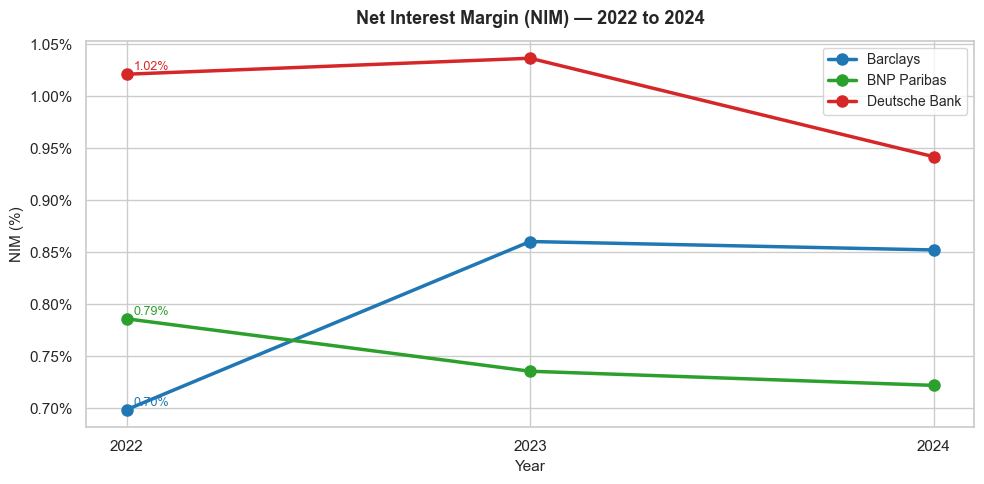

In [34]:

fig, ax = plt.subplots(figsize=(10, 5))


for name in banks:
    values = ratios[name]["NIM (%)"][years].values
    ax.plot(year_labels, values,
            marker="o", linewidth=2.5, markersize=8,
            color=bank_colours[name], label=name)
    # Label the 2024 data point directly on the chart
    ax.annotate(f"{values[0]:.2f}%",
                xy=(year_labels[0], values[0]),
                xytext=(5, 3), textcoords="offset points",
                fontsize=9, color=bank_colours[name])

ax.set_title("Net Interest Margin (NIM) — 2022 to 2024",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("NIM (%)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))
plt.tight_layout()
plt.savefig("../outputs/nim_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

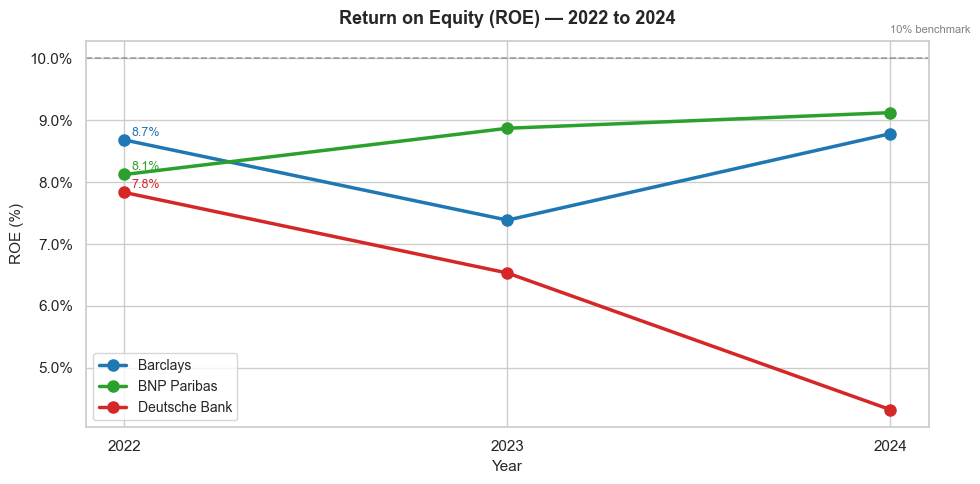

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))

for name in banks:
    values = ratios[name]["ROE (%)"][years].values
    ax.plot(year_labels, values,
            marker="o", linewidth=2.5, markersize=8,
            color=bank_colours[name], label=name)
    ax.annotate(f"{values[0]:.1f}%",
                xy=(year_labels[0], values[0]),
                xytext=(5, 3), textcoords="offset points",
                fontsize=9, color=bank_colours[name])

# The 10% line is the informal minimum target for European banks
# A bank consistently below this is arguably not earning its cost of equity
ax.axhline(y=10, color="grey", linestyle="--", linewidth=1.2, alpha=0.7)
ax.text(year_labels[-1], 10.4, "10% benchmark", fontsize=8, color="grey")

ax.set_title("Return on Equity (ROE) — 2022 to 2024",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("ROE (%)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
plt.tight_layout()
plt.savefig("../outputs/roe_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

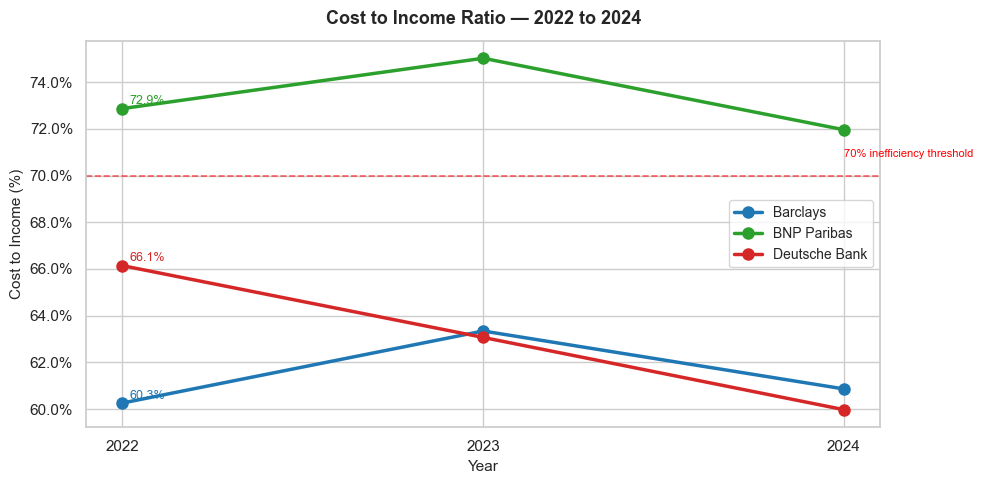

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

for name in banks:
    values = ratios[name]["Cost to Income (%)"][years].values
    ax.plot(year_labels, values,
            marker="o", linewidth=2.5, markersize=8,
            color=bank_colours[name], label=name)
    ax.annotate(f"{values[0]:.1f}%",
                xy=(year_labels[0], values[0]),
                xytext=(5, 3), textcoords="offset points",
                fontsize=9, color=bank_colours[name])

# Above 70% is generally considered operationally inefficient
ax.axhline(y=70, color="red", linestyle="--", linewidth=1.2, alpha=0.6)
ax.text(year_labels[-1], 70.8, "70% inefficiency threshold", fontsize=8, color="red")

ax.set_title("Cost to Income Ratio — 2022 to 2024",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Cost to Income (%)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
plt.tight_layout()
plt.savefig("../outputs/cost_to_income.png", dpi=150, bbox_inches="tight")
plt.show()

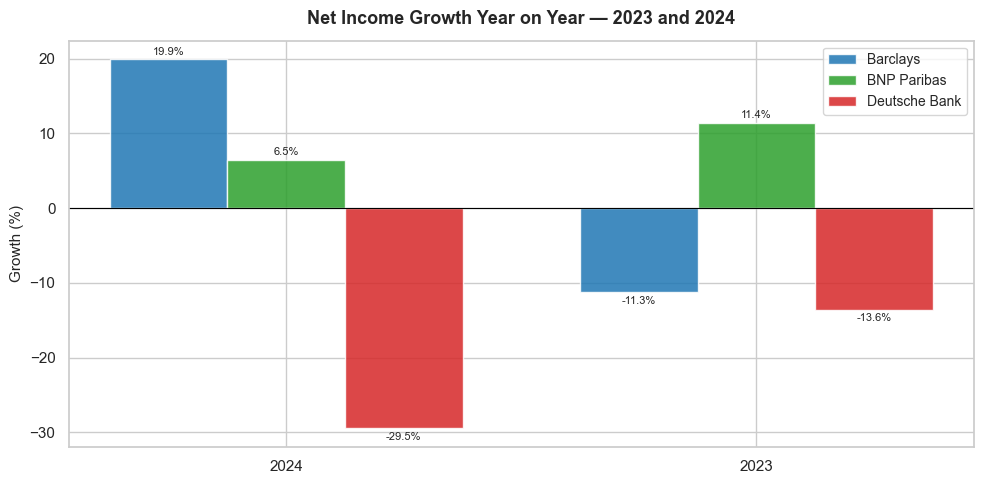

In [38]:
# Growth is only available for 2024 and 2023
# 2022 growth would need 2021 data which is incomplete for two of the banks
growth_years  = ["2024-12-31", "2023-12-31"]
growth_labels = ["2024", "2023"]

x     = np.arange(len(growth_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, name in enumerate(banks):
    values = ratios[name]["Net Income Growth (%)"][growth_years].values
    bars   = ax.bar(x + (i - 1) * width, values, width,
                    label=name, color=bank_colours[name], alpha=0.85)
    for bar, val in zip(bars, values):
        if not np.isnan(val):
            offset = 0.3 if val >= 0 else -1.8
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + offset,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=8)

ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_title("Net Income Growth Year on Year — 2023 and 2024",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Growth (%)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(growth_labels, fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/net_income_growth.png", dpi=150, bbox_inches="tight")
plt.show()

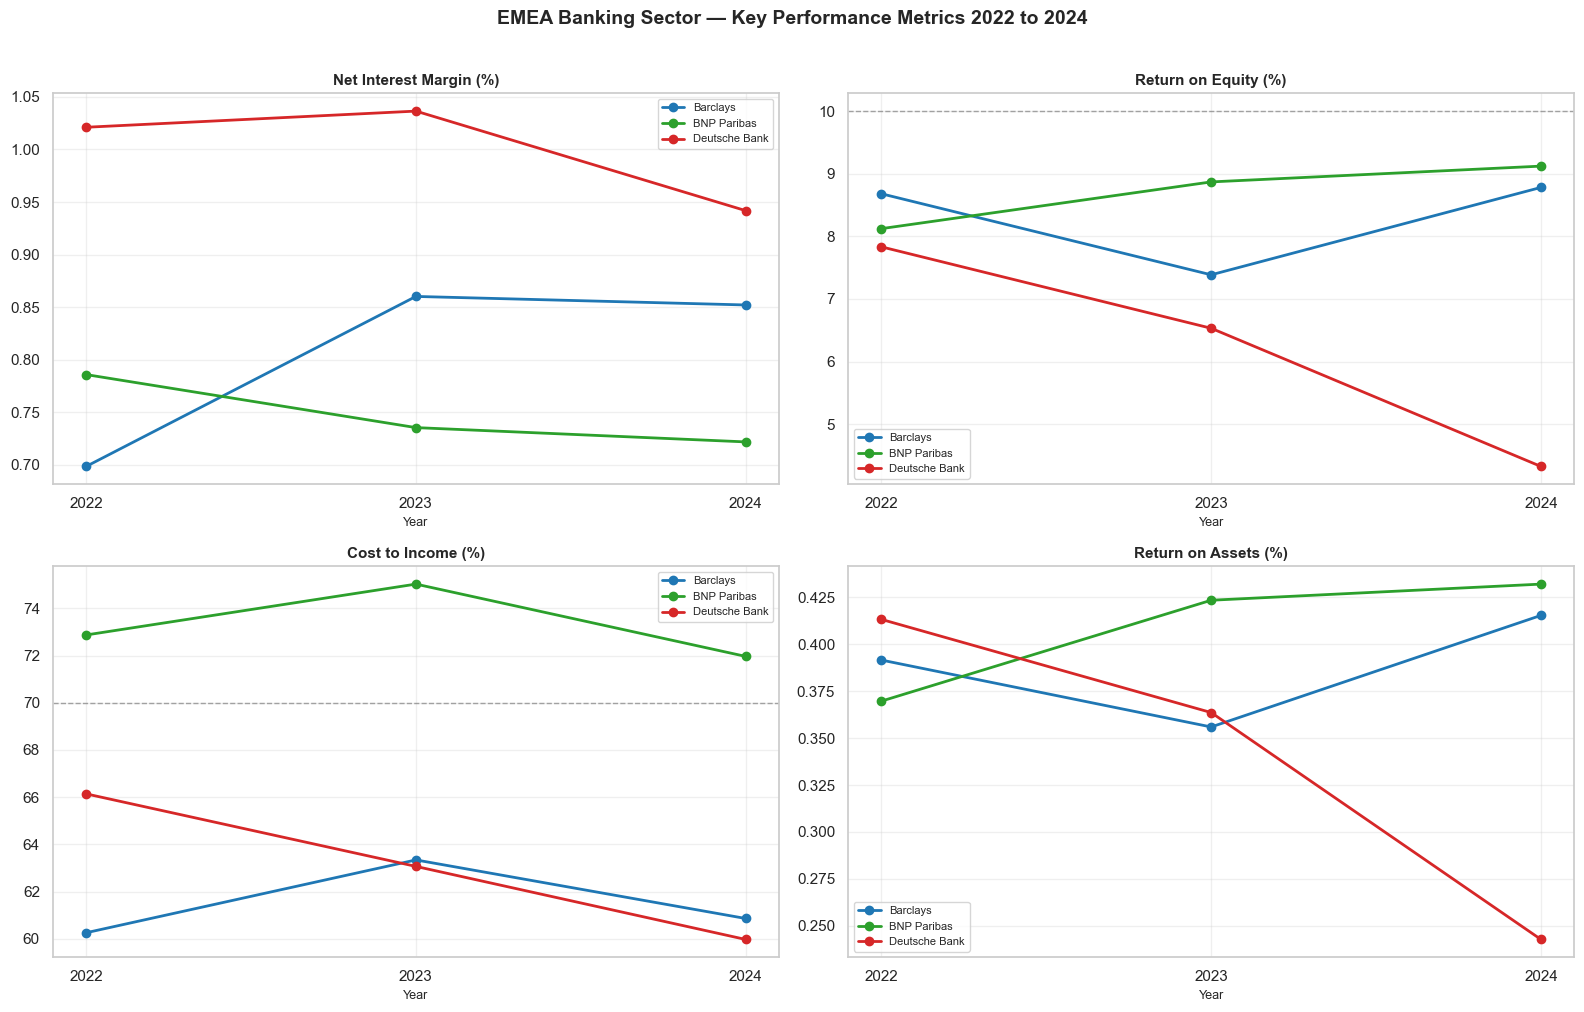

Dashboard saved.


In [39]:
# A combined view of all four key metrics — the kind of layout you would
# see in a real research publication or investor presentation

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("EMEA Banking Sector — Key Performance Metrics 2022 to 2024",
             fontsize=14, fontweight="bold", y=1.01)

# Each tuple: metric key, chart title, axis, add benchmark line, benchmark value
panels = [
    ("NIM (%)",            "Net Interest Margin (%)",  axes[0, 0], False, None),
    ("ROE (%)",            "Return on Equity (%)",     axes[0, 1], True,  10),
    ("Cost to Income (%)", "Cost to Income (%)",       axes[1, 0], True,  70),
    ("ROA (%)",            "Return on Assets (%)",     axes[1, 1], False, None),
]

for metric_key, title, ax, add_line, line_val in panels:
    for name in banks:
        values = ratios[name][metric_key][years].values
        ax.plot(year_labels, values,
                marker="o", linewidth=2, markersize=6,
                color=bank_colours[name], label=name)
    if add_line and line_val is not None:
        ax.axhline(y=line_val, color="grey", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Year", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/dashboard_ratios.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved.")

In [40]:
# Deutsche Bank does not report a single "Operating Expense" field
# Instead we reconstruct it by adding its component cost lines together
# This is common in real financial analysis — not all banks report identically

db_inc = income["Deutsche Bank"]

# These are the cost fields Deutsche Bank actually reports
# We checked these exist in Notebook 1 when we printed all available fields
selling_ga     = pd.to_numeric(db_inc.loc["Selling General And Administration"], errors="coerce")
non_int_exp    = pd.to_numeric(db_inc.loc["Other Non Interest Expense"],         errors="coerce")

# Add them together to get total operating cost, convert to billions
db_operating_expense = (selling_ga + non_int_exp)[years] / 1e9

# Update raw_data with the corrected figure
raw_data["Deutsche Bank"]["operating_expense"] = db_operating_expense

# Recalculate cost to income for Deutsche Bank using the corrected expense figure
db_revenue = raw_data["Deutsche Bank"]["total_revenue"]
ratios["Deutsche Bank"]["Cost to Income (%)"] = (db_operating_expense / db_revenue) * 100

print("Deutsche Bank operating expense reconstructed:")
print(db_operating_expense.round(2))
print("\nDeutsche Bank Cost to Income (%) corrected:")
print(ratios["Deutsche Bank"]["Cost to Income (%)"].round(2))

Deutsche Bank operating expense reconstructed:
2022-12-31    17.63
2023-12-31    18.21
2024-12-31    18.02
dtype: float64

Deutsche Bank Cost to Income (%) corrected:
2022-12-31    66.14
2023-12-31    63.07
2024-12-31    59.97
dtype: float64


In [41]:
# Save everything as a flat CSV — one row per bank per year
# Notebook 3 reads this directly so it doesn't need to recalculate anything

rows = []
for name in banks:
    for year, label in zip(years, year_labels):
        rows.append({
            "Bank"               : name,
            "Year"               : label,
            "NIM (%)"            : round(ratios[name]["NIM (%)"][year], 4),
            "ROE (%)"            : round(ratios[name]["ROE (%)"][year], 4),
            "ROA (%)"            : round(ratios[name]["ROA (%)"][year], 4),
            "Cost to Income (%)": round(ratios[name]["Cost to Income (%)"][year], 4),
            "Net Income (bn)"    : round(ratios[name]["Net Income (bn)"][year], 4),
        })

ratios_df = pd.DataFrame(rows)
ratios_df.to_csv("../data/ratios_summary.csv", index=False)

print("Saved to ../data/ratios_summary.csv")
print()
print(ratios_df.to_string(index=False))

Saved to ../data/ratios_summary.csv

         Bank Year  NIM (%)  ROE (%)  ROA (%)  Cost to Income (%)  Net Income (bn)
     Barclays 2022   0.6984   8.6804   0.3916             60.2574            5.928
     Barclays 2023   0.8602   7.3858   0.3559             63.3431            5.259
     Barclays 2024   0.8521   8.7816   0.4154             60.8616            6.307
  BNP Paribas 2022   0.7858   8.1229   0.3697             72.8726            9.848
  BNP Paribas 2023   0.7354   8.8693   0.4235             75.0280           10.975
  BNP Paribas 2024   0.7218   9.1215   0.4321             71.9645           11.688
Deutsche Bank 2022   1.0211   7.8328   0.4133             66.1427            5.525
Deutsche Bank 2023   1.0365   6.5322   0.3636             63.0684            4.772
Deutsche Bank 2024   0.9418   4.3250   0.2427             59.9727            3.366


In [ ]:
# This is the most important cell in the notebook
# Numbers without interpretation are just numbers
# This is where data analysis becomes financial analysis

print("""
NET INTEREST MARGIN
All three banks saw NIM improve from 2022 to 2024, driven by the ECB
and Bank of England rate hiking cycles. Higher central bank rates let
banks widen the spread between lending rates and deposit rates.
The key question going forward is how quickly NIM compresses as the
ECB begins cutting rates through 2024 and 2025.

RETURN ON EQUITY
Barclays and BNP Paribas have both approached or crossed the 10%
benchmark. Deutsche Bank has improved significantly from its
restructuring lows but still lags peers, its ROE trajectory
remains the central question for its investment case.

COST TO INCOME
BNP Paribas carries the highest cost base, reflecting its large
European retail network. Barclays has been more aggressive on costs.
Deutsche Bank's ratio has improved materially, the clearest sign
its multi-year restructuring programme is working.

NET INCOME GROWTH
All three banks grew net income year on year, benefiting from the
higher rate environment. The question for Notebook 3 is whether this
improvement is already priced into the stock, or whether the market
is still discounting these banks more than fundamentals justify.
""")




NET INTEREST MARGIN
All three banks saw NIM improve from 2022 to 2024, driven by the ECB
and Bank of England rate hiking cycles. Higher central bank rates let
banks widen the spread between lending rates and deposit rates.
The key question going forward is how quickly NIM compresses as the
ECB begins cutting rates through 2024 and 2025.

RETURN ON EQUITY
Barclays and BNP Paribas have both approached or crossed the 10%
benchmark. Deutsche Bank has improved significantly from its
restructuring lows but still lags peers — its ROE trajectory
remains the central question for its investment case.

COST TO INCOME
BNP Paribas carries the highest cost base, reflecting its large
European retail network. Barclays has been more aggressive on costs.
Deutsche Bank's ratio has improved materially — the clearest sign
its multi-year restructuring programme is working.

NET INCOME GROWTH
All three banks grew net income year on year, benefiting from the
higher rate environment. The question for Notebook